In [1]:
# List all files in the Kaggle input directory to confirm dataset location and file organization.
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)


In [22]:
# Import necessary packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import f1_score, confusion_matrix, roc_auc_score, roc_curve, classification_report


In [3]:
# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# Automatically select GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Root directory where the dataset images and CSV files are stored
DATA_ROOT = "/kaggle/input/datasets/spark2025/spark-2026-chestxray/dataset"

# Full paths to the CSV files
TRAIN_CSV = os.path.join(DATA_ROOT, "train.csv")
VAL_CSV   = os.path.join(DATA_ROOT, "val.csv")
TEST_CSV  = os.path.join(DATA_ROOT, "test.csv")

In [5]:
# Custom PyTorch Dataset for loading chest X-ray images from CSV files
class ChestXRayDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, is_test=False):
        self.df = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        self.is_test = is_test
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Build full image path: root_dir + filepath from CSV
        rel_path = self.df.iloc[idx]['filepath']
        img_path = os.path.join(self.root_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)

        # Return only image for test set; otherwise return (image, label)
        if self.is_test:
            return image
        else:
            label = self.df.iloc[idx]['target']
            return image, label


In [6]:
# Target image size (224x224) is standard for ResNet50
IMG_SIZE = 224

# Mean and std for normalization (computed from ImageNet statistics)
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

# Training transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Validation/test transforms
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [7]:
# Instantiate datasets for training, validation, and test
train_dataset = ChestXRayDataset(TRAIN_CSV, DATA_ROOT, transform=train_transform, is_test=False)
val_dataset   = ChestXRayDataset(VAL_CSV,   DATA_ROOT, transform=val_test_transform, is_test=False)
test_dataset  = ChestXRayDataset(TEST_CSV,  DATA_ROOT, transform=val_test_transform, is_test=True)

BATCH_SIZE = 32

# DataLoaders for efficient batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)


In [20]:
class PneumoniaResNet50(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()

        # Load ResNet50 WITHOUT pretrained weights
        backbone = models.resnet50(weights=None)

        # Keep feature extractor (everything except FC)
        self.features = nn.Sequential(*list(backbone.children())[:-2])

        # Extra layers (your "add more layers")
        self.extra_conv = nn.Sequential(
            nn.Conv2d(2048, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),

            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)        # ResNet50 backbone
        x = self.extra_conv(x)      # your added depth
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [23]:
# Create model instance and move it to the selected device (CPU/GPU)
model = PneumoniaResNet50().to(device)
print(model)

PneumoniaResNet50(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): 

In [25]:
# Count from training set
train_df = pd.read_csv('/kaggle/input/datasets/spark2025/spark-2026-chestxray/dataset/train.csv')
num_normal = len(train_df[train_df['target'] == 0])
num_pneumonia = len(train_df[train_df['target'] == 1])

# Compute positive weight to handle class imbalance (more pneumonia than normal)
pos_weight = torch.tensor([num_normal / num_pneumonia]).to(device)
print(f"Positive weight for BCEWithLogitsLoss: {pos_weight.item():.3f}")

# Loss function with class weighting
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Positive weight for BCEWithLogitsLoss: 0.370


In [26]:
LEARNING_RATE = 1e-3
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Reduce learning rate when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)


In [27]:
# Perform one full pass over the training data
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        preds = torch.sigmoid(outputs) >= 0.5
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [28]:
# Evaluate the model on validation data
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device).float().unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(outputs)
            preds = probs >= 0.5
            
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy().flatten())
            all_preds.extend(preds.cpu().numpy().flatten())
            all_probs.extend(probs.cpu().numpy().flatten())
            
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    # Compute metrics
    f1 = f1_score(all_labels, all_preds, average='macro')
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0
    cm = confusion_matrix(all_labels, all_preds)
    
    return epoch_loss, epoch_acc, f1, auc, cm, all_labels, all_probs


In [29]:
NUM_EPOCHS = 10
best_val_f1 = 0.0
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, val_auc, cm, _, _ = validate(model, val_loader, criterion, device)
    
    # Adjust learning rate based on validation loss
    scheduler.step(val_loss)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f} | Val F1: {val_f1:.4f} | Val AUC: {val_auc:.4f}")
    
    # Save best model based on macro F1
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"  ** Saved new best model with F1: {val_f1:.4f} **")
    print()

Epoch 01/10
  Train Loss: 0.1837 | Train Acc: 0.8512
  Val Loss:   0.1195 | Val Acc:   0.9248 | Val F1: 0.9041 | Val AUC: 0.9768
  ** Saved new best model with F1: 0.9041 **

Epoch 02/10
  Train Loss: 0.1283 | Train Acc: 0.9080
  Val Loss:   0.3726 | Val Acc:   0.6834 | Val F1: 0.6763 | Val AUC: 0.9719

Epoch 03/10
  Train Loss: 0.1167 | Train Acc: 0.9175
  Val Loss:   0.0971 | Val Acc:   0.9271 | Val F1: 0.9107 | Val AUC: 0.9804
  ** Saved new best model with F1: 0.9107 **

Epoch 04/10
  Train Loss: 0.1148 | Train Acc: 0.9195
  Val Loss:   0.0873 | Val Acc:   0.9328 | Val F1: 0.9168 | Val AUC: 0.9852
  ** Saved new best model with F1: 0.9168 **

Epoch 05/10
  Train Loss: 0.1058 | Train Acc: 0.9234
  Val Loss:   0.2500 | Val Acc:   0.8964 | Val F1: 0.8486 | Val AUC: 0.9882

Epoch 06/10
  Train Loss: 0.1067 | Train Acc: 0.9207
  Val Loss:   0.6485 | Val Acc:   0.5216 | Val F1: 0.5216 | Val AUC: 0.9052

Epoch 07/10
  Train Loss: 0.1102 | Train Acc: 0.9290
  Val Loss:   0.1337 | Val Acc: 

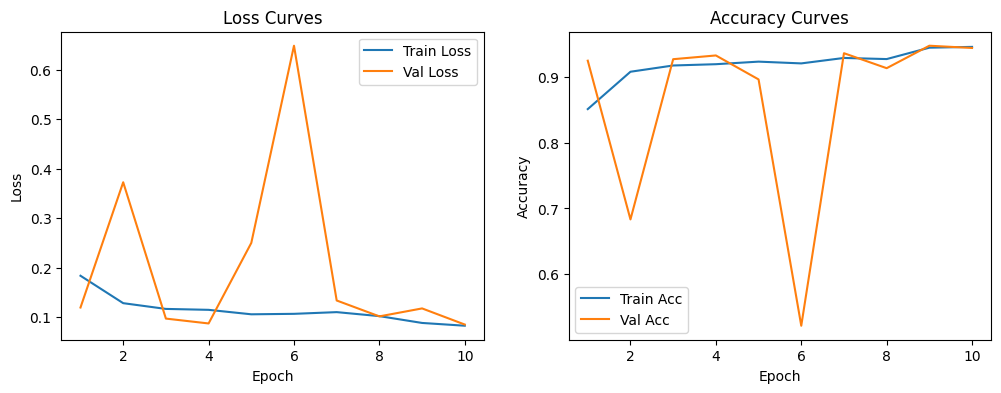

In [30]:
plt.figure(figsize=(12,4))

# Loss curves
plt.subplot(1,2,1)
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label='Train Loss')
plt.plot(range(1, NUM_EPOCHS+1), val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curves')

# Accuracy curves
plt.subplot(1,2,2)
plt.plot(range(1, NUM_EPOCHS+1), train_accs, label='Train Acc')
plt.plot(range(1, NUM_EPOCHS+1), val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curves')

plt.show()

In [31]:
# Load the model weights that achieved the highest validation macro F1
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

# Re-run validation to obtain final metrics
val_loss, val_acc, val_f1, val_auc, cm, all_labels, all_probs = validate(model, val_loader, criterion, device)

print("=== Final Validation Performance ===")
print(f"Loss:      {val_loss:.4f}")
print(f"Accuracy:  {val_acc:.4f}")
print(f"Macro F1:  {val_f1:.4f}")
print(f"AUC-ROC:   {val_auc:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(all_labels, (np.array(all_probs) >= 0.5).astype(int), target_names=['Normal', 'Pneumonia']))


=== Final Validation Performance ===
Loss:      0.1177
Accuracy:  0.9476
Macro F1:  0.9303
AUC-ROC:   0.9901

Confusion Matrix:
[[197  40]
 [  6 635]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.83      0.90       237
   Pneumonia       0.94      0.99      0.97       641

    accuracy                           0.95       878
   macro avg       0.96      0.91      0.93       878
weighted avg       0.95      0.95      0.95       878



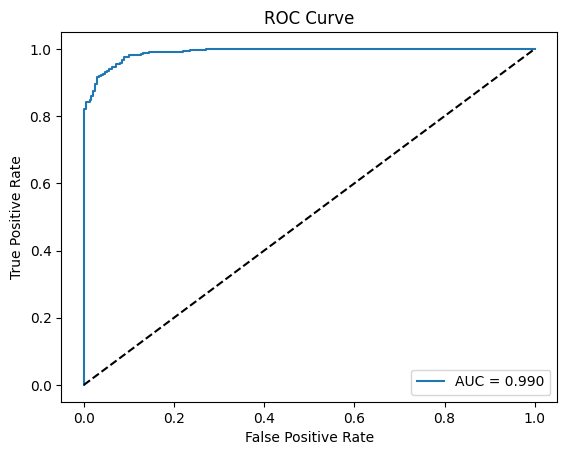

In [32]:
# ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {val_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [33]:
# Generate predictions for test set
test_predictions = []
test_ids = []

with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).cpu().numpy().flatten().astype(int)
        test_predictions.extend(preds)

# Get test IDs from test.csv
test_df = pd.read_csv(TEST_CSV)
test_ids = test_df['id'].tolist()

In [34]:
# Create submission DataFrame and save as CSV
submission = pd.DataFrame({'id': test_ids, 'target': test_predictions})
submission.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'")
print(submission.head())

Submission file saved as 'submission.csv'
          id  target
0  CXR_05741       1
1  CXR_03646       1
2  CXR_00870       1
3  CXR_04969       1
4  CXR_01893       1
